In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer

In [2]:
df = pd.read_csv("data/credit_risk_dataset.csv")
df = df.drop_duplicates().copy()

In [4]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Clean invalid rows
def clean_invalid_rows(df):
    df = df.copy()
    df = df[(df["person_age"] > 0) & (df["person_age"] < 100)]
    df = df[df["person_income"] > 0]
    df = df[df["loan_amnt"] > 0]
    df = df[(df["person_emp_length"].isna()) | ((df["person_emp_length"] >= 0) & (df["person_emp_length"] <= 50))]
    df = df[(df["person_emp_length"].isna()) | (df["person_emp_length"] <= df["person_age"])]
    df = df[(df["loan_int_rate"].isna()) | (df["loan_int_rate"] > 0)]
    return df

# Cleaned the training and test sets separately to preserve the independence of the test set and avoid data leakage
X_train = clean_invalid_rows(X_train)
y_train = y_train.loc[X_train.index]
X_test = clean_invalid_rows(X_test)
y_test = y_test.loc[X_test.index]

#Add engineered features

def add_engineered_features(df):
    df = df.copy()
    df["income_to_loan_ratio"] = df["person_income"] / df["loan_amnt"]
    df["emp_length_to_age_ratio"] = df["person_emp_length"] / df["person_age"]
    return df

X_train = add_engineered_features(X_train)
X_test = add_engineered_features(X_test)


# Scale

categorical_features = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

log_features = ["person_income", "loan_amnt", "income_to_loan_ratio"]

numeric_features = [
    "person_age",
    "person_emp_length",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "emp_length_to_age_ratio"
]

# Log transform compresses large values and makes the distribution more balanced
log_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p, validate=False, feature_names_out="one-to-one")),
    ("scaler", StandardScaler())
])

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("log_num", log_transformer, log_features),
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Train processed shape:", X_train_processed.shape)
print("Test processed shape:", X_test_processed.shape)
feature_names = preprocessor.get_feature_names_out()



Train processed shape: (25925, 28)
Test processed shape: (6484, 28)


In [5]:
X_train_processed.shape


(25925, 28)

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    brier_score_loss
)

tree_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)


In [7]:
tree_model.fit(X_train_processed, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [8]:
# Predict class labels
y_train_pred = tree_model.predict(X_train_processed)
y_test_pred = tree_model.predict(X_test_processed)

# Predict probabilities for default = 1
y_train_proba = tree_model.predict_proba(X_train_processed)[:, 1]
y_test_proba = tree_model.predict_proba(X_test_processed)[:, 1]


In [9]:
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

print("Test ROC-AUC:", roc_auc_score(y_test, y_test_proba))
print("Test Brier Score:", brier_score_loss(y_test, y_test_proba))

Train Accuracy: 0.8903375120540019
Test Accuracy: 0.8904996915484269

Confusion Matrix:
[[4734  332]
 [ 378 1040]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      5066
           1       0.76      0.73      0.75      1418

    accuracy                           0.89      6484
   macro avg       0.84      0.83      0.84      6484
weighted avg       0.89      0.89      0.89      6484

Test ROC-AUC: 0.8780166679937659
Test Brier Score: 0.10434260227495101


In [10]:
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": tree_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance_df.head(15)

,feature,importance
2,log_num__income_to_loan_ratio,0.354623
5,num__loan_int_rate,0.298419
0,log_num__person_income,0.147905
12,cat__person_home_ownership_RENT,0.063063
22,cat__loan_grade_D,0.056281
21,cat__loan_grade_C,0.039461
11,cat__person_home_ownership_OWN,0.023783
4,num__person_emp_length,0.011168
8,num__emp_length_to_age_ratio,0.001868
14,cat__loan_intent_EDUCATION,0.001793


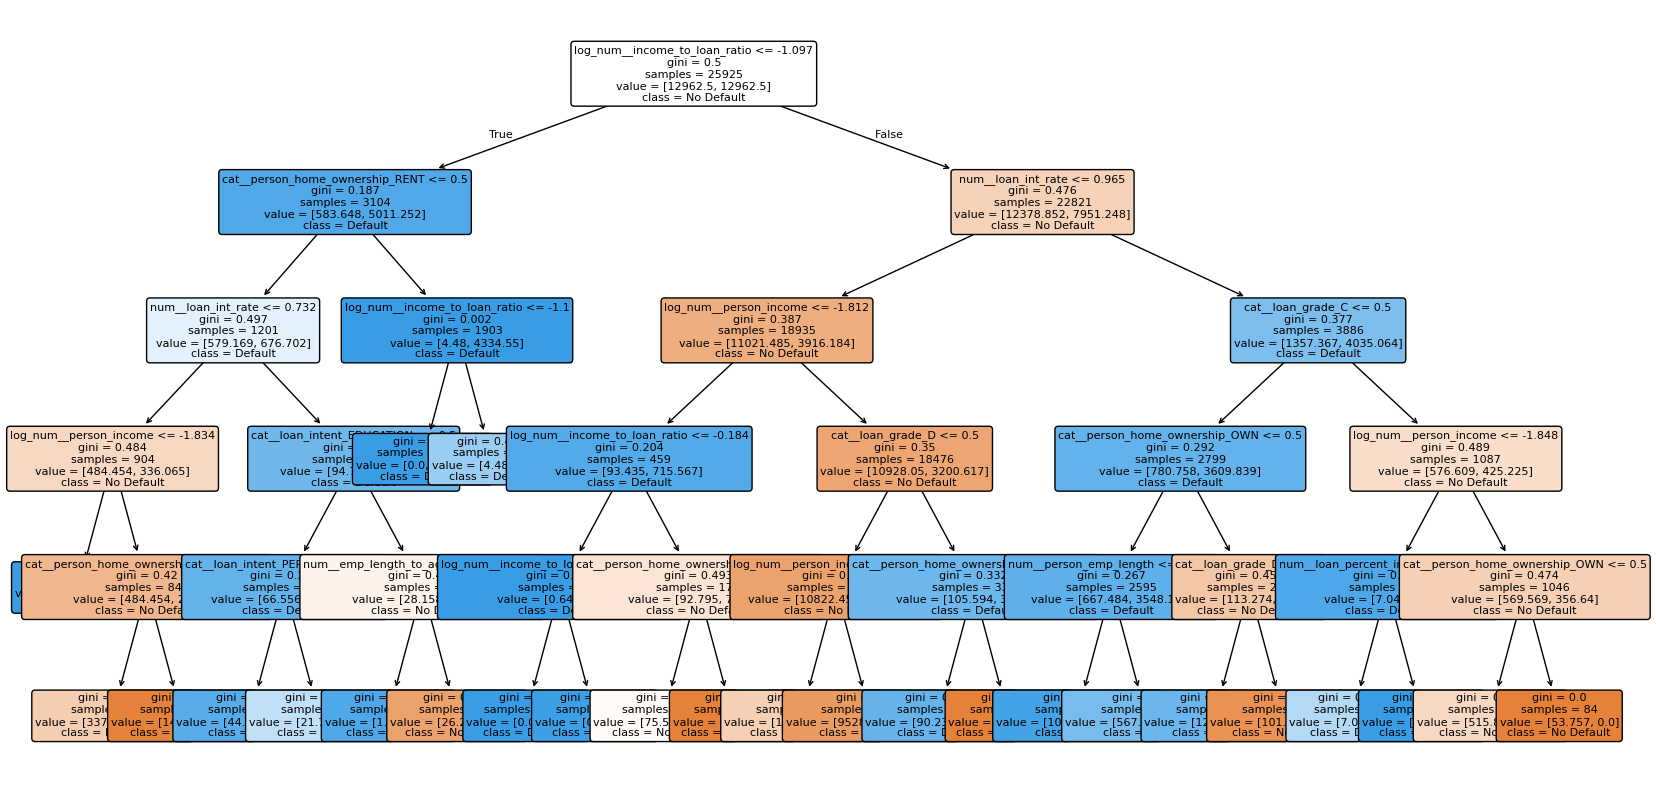

In [11]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["No Default", "Default"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()